# UK road‑crash severity & deprivation — a resource‑prioritisation analysis
# 英国车祸严重度与贫困 —— 一项资源优先级分析

## Business problem / 商业问题
**A regional road‑safety team needs to prioritise limited KSI‑prevention resources by identifying the road *contexts* and *areas* where collisions are more likely to become serious or fatal, and where the absolute KSI burden per vehicle‑mile is highest.** / **区域道路安全团队需要在有限预算下,识别"哪些道路情境与地区的车祸更易致重伤/致命、且每车英里的绝对 KSI 负担最高",据此优先分配 KSI 预防资源。**

- **Decision‑maker / 决策者:** a local authority / regional road‑safety team / transport‑safety planners. / 地方政府 / 区域道路安全团队 / 交通安全规划者。
- **What the decision is — and is NOT / 决策是什么、不是什么:** the goal is **not** to predict each individual future crash in real time. Many recorded fields (weather, light, road surface, vehicle type) are only known **at or after** the collision, so this is a **retrospective risk‑context / resource‑prioritisation analysis**: characterise *which conditions and areas carry higher severity and higher KSI burden* so prevention effort can be targeted. / 目标**不是**实时预测每一起未来事故——天气/光照/路面/车型等是事故**当时或之后**才记录的,故这是**回顾性的风险情境 / 资源优先级分析**:刻画"哪些条件与地区严重度更高、KSI 负担更重",以定向投放预防力量。
- **Why the cost is asymmetric / 成本不对称:** flagging a context that turns out severe and acting on it prevents a death or life‑changing injury — far more valuable than attention spent on a lower‑risk context. / 标出会致重伤的情境并干预 = 避免一条人命,远比多关注一个低风险情境值钱。
- **Intended use / 用途:** outputs support **road‑safety interventions** (engineering, enforcement, resource allocation) — **not automated individual‑level decisions**. / 产出服务于**道路安全干预**(工程/执法/资源分配),**非个体层面自动决策**。

## Three questions / 三个问题
1. Can road **context** characterise how severe a collision becomes (and how well)? / 道路**情境**能多大程度刻画严重度?
2. Which conditions are associated with higher severity? / 哪些条件与更高严重度相关?
3. Does the burden fall unequally across rich vs poor areas — conditional severity, and absolute burden per vehicle‑mile? / 负担在贫富地区间是否不均——条件严重度 vs 每车英里绝对负担?

## How to run this notebook / 如何运行
- **Python** ≥ 3.10. Install packages: `pip install -r requirements.txt` (pandas, numpy, scikit‑learn, xgboost, shap, statsmodels, scipy, matplotlib, seaborn, openpyxl). / 装包见 requirements.txt。
- **Data:** place the dataset files in a **`data/`** folder next to this notebook (filenames are listed in the *Paths & files* cell; sources in *Data provenance*). / 数据放在与本 notebook 同级的 **`data/`** 文件夹(文件名见"路径与文件"格,来源见"数据来源")。
- **Outputs:** figures/tables are written to **`outputs/`** (auto‑created). / 图表输出到 **`outputs/`**(自动创建)。
- **Reproduce:** run top‑to‑bottom (`Run All`). Seeds are fixed; results do not depend on run order. A reproducibility checklist is at the end. / 从上到下一键运行即可复现;种子已固定;末尾有复现 checklist。

## 1. Setup — imports, config, paths, filenames / 环境 · 配置 · 路径 · 文件名
**Why centralised / 为什么集中:** one place for all imports, the random seed, warning policy and (relative) paths makes the notebook reproducible and easy to audit. / 所有 import / 种子 / 警告策略 / 相对路径集中一处,便于复现与审计。

In [1]:
# --- imports (all used below) ---
import warnings, sys
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, recall_score, precision_score)
from sklearn.metrics import silhouette_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import spearmanr
import shap

# --- config: reproducibility + clean output (n_jobs=1 avoids loky/ResourceTracker noise) ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
N_JOBS = 1                      # single-process: deterministic + no multiprocessing warnings
warnings.filterwarnings("ignore", category=FutureWarning)     # benign lib deprecations only
warnings.filterwarnings("ignore", message=".*use_inf_as_na.*")
pd.set_option("display.max_columns", 60); sns.set_theme(style="whitegrid")

# --- relative paths (NO machine-specific absolute paths) ---
BASE   = Path(".")
DATA   = BASE / "data"
OUTPUT = BASE / "outputs"; OUTPUT.mkdir(exist_ok=True)
assert DATA.exists(), "Put the data files in ./data/ (see 'How to run' + 'Data provenance')."

# --- filenames managed in ONE place (avoid hard-coding long names across cells) ---
F_ACCIDENTS = "Road Accident Data.csv"                                  # Kaggle STATS19-style, 2021-22
F_IMD_LAD   = "File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx"
F_IMD_LSOA  = "File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv"
F_TRAFFIC   = "local_authority_traffic.csv"                             # DfT vehicle-miles by LA
F_LAD2CTY   = "LAD17_CTYUA17_EW_LU.csv"                                 # district -> county lookup
F_STATS19   = "stats19_collisions_2015_2024_subset.csv"                # official multi-year (robustness)
print("env OK |", "python", sys.version.split()[0])

env OK | python 3.13.5


In [2]:
# Package versions (reproducibility record)
import sklearn, xgboost, statsmodels, scipy, matplotlib
for m in [np, pd, sklearn, xgboost, shap, statsmodels, scipy, matplotlib, sns]:
    print(f"{m.__name__:14s} {getattr(m,'__version__','?')}")

numpy          2.1.3
pandas         2.2.3
sklearn        1.6.1
xgboost        3.2.0
shap           0.52.0
statsmodels    0.14.4
scipy          1.15.3
matplotlib     3.10.0
seaborn        0.13.2


## 2. Load data / 加载数据
**Why read the index as text / 为什么索引读成文本:** the `Accident_Index` column was corrupted by Excel into scientific notation (`2.01E+12`) for a large share of rows; reading as string stops further coercion (and §3 explains why we never key on it). / `Accident_Index` 被 Excel 损坏成科学计数法,读成字符串防再损坏(§3 说明绝不拿它当键)。

In [3]:
acc = pd.read_csv(DATA/F_ACCIDENTS, encoding="utf-8-sig", dtype={"Accident_Index":str}, low_memory=False)
acc["KSI"] = acc["Accident_Severity"].isin(["Serious","Fatal"]).astype(int)   # KSI = Killed or Seriously Injured (official DfT outcome)
print("shape:", acc.shape)
acc.head(3)

shape: (307973, 24)


,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,KSI
0,200901BS70001,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,-0.201349,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car,1
1,200901BS70002,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,-0.199248,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car,1
2,200901BS70003,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,-0.179599,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car,0


## 3. Data provenance & quality / 数据来源与质量
**Sources / 来源:** primary = **Kaggle STATS19‑style GB collision dataset** (`xavierberge/road-accident-dataset`, 2021–22). External joins: **IMD 2019 deprivation** (gov.uk; LAD `File_10`, LSOA `File_7`), **DfT local‑authority traffic / vehicle‑miles**, **ONS LAD→county lookup**, and (robustness only, §‑Robustness) **official multi‑year STATS19 1979–2024**. / 主集 Kaggle STATS19 式碰撞(2021–22);外接 IMD 2019、DfT 车英里、ONS 区→郡对照,稳健性另用官方多年 STATS19。
**Handling notes / 处理说明:** (a) `Accident_Index` Excel scientific‑notation corruption → never used as a key (dedup/grouping/clustered‑SE use whole rows or LAD); (b) the raw date string is largely unparseable → we use the reliable integer `Year`; (c) STATS19 "unknown / data missing or out of range" **sentinels** are recoded to NaN so the model learns crash context, not the data‑collection process. / (a)损坏ID绝不当键;(b)用可靠的 Year 列;(c)哨兵值转 NaN。

In [4]:
# Data quality summary table
acc["_date"] = pd.to_datetime(acc["Accident Date"], errors="coerce", dayfirst=True)
idx_top = acc["Accident_Index"].value_counts().iloc[0]
dq = pd.DataFrame({
  "metric":["rows","columns","year range","whole-row duplicates",
            "Accident_Index corrupted to one value","KSI positive rate",
            "missing: Weather_Conditions","missing: Road_Type","speed_limit range","lat/long within GB"],
  "value":[f"{len(acc):,}", acc.shape[1], f"{int(acc.Year.min())}–{int(acc.Year.max())}",
           int(acc.duplicated().sum()), f"{idx_top:,} rows ({idx_top/len(acc):.0%})",
           f"{acc.KSI.mean():.3f}", f"{acc.Weather_Conditions.isna().mean():.1%}",
           f"{acc.Road_Type.isna().mean():.1%}", f"{int(acc.Speed_limit.min())}–{int(acc.Speed_limit.max())} mph",
           f"lat {acc.Latitude.min():.1f}–{acc.Latitude.max():.1f}, lng {acc.Longitude.min():.1f}–{acc.Longitude.max():.1f}"]})
print(dq.to_string(index=False))

                               metric                       value
                                 rows                     307,973
                              columns                          25
                           year range                   2021–2022
                 whole-row duplicates                           1
Accident_Index corrupted to one value          110,304 rows (36%)
                    KSI positive rate                       0.145
          missing: Weather_Conditions                        2.0%
                   missing: Road_Type                        0.5%
                    speed_limit range                   10–70 mph
                   lat/long within GB lat 49.9–60.6, lng -7.5–1.8


📊 **Read‑out / 结果解读:** ~**308k** real GB collisions (2021–22), KSI rate **14.5%**, only **1** whole‑row duplicate, valid GB geo and the exact DfT speed ladder, low missingness — a large, genuine sample. The one red flag is the **`Accident_Index` Excel corruption (36% of rows share `2.01E+12`)**, which is why it is never used as a key. / ~30.8万真实碰撞(2021–22),KSI 14.5%,整行重复仅 1,地理/限速合法、缺失低=真实大样本;唯一警报是 `Accident_Index` 36% 损坏 → 绝不当键。

## 4. Is the data real? (authenticity) / 数据是真的吗?
**Why / 为什么:** many Kaggle sets are synthetic and inflate model AUC; two cheap statistical tells of real data: every feature's univariate AUC vs the target is modest (no trivial separator), and geography/speeds match the real DfT coding. / 验真伪:单特征 AUC 朴素 + 地理/限速吻合官方编码。

In [5]:
print("Severity distribution:\n", acc.Accident_Severity.value_counts().to_string())
print(f"\nKSI rate = {acc.KSI.mean():.4f} (n={acc.KSI.sum():,})")
print("Univariate AUC -> KSI (≈0.5 = no trivial separator):")
for c in ["Speed_limit","Latitude","Longitude"]:
    a=roc_auc_score(acc.KSI, acc[c].fillna(acc[c].median())); print(f"  {c:11s} {max(a,1-a):.3f}")

Severity distribution:
 Accident_Severity
Slight     263280
Serious     40740
Fatal        3953

KSI rate = 0.1451 (n=44,693)
Univariate AUC -> KSI (≈0.5 = no trivial separator):
  Speed_limit 0.547
  Latitude    0.513
  Longitude   0.500


📊 **Read‑out / 结果解读:** every at‑scene feature's univariate AUC sits at **0.50–0.55** (no trivial separator) and geography/speeds match real DfT coding → genuinely collected data, safe to treat as real‑world evidence. / 单特征 AUC 0.50–0.55、无平凡分离,地理/限速吻合官方编码 → 真实数据。

## 5. Target & Leakage Control / 目标与泄漏控制
**Target / 目标:** binary **KSI** (Killed‑or‑Seriously‑Injured) — the official DfT policy outcome, a citable convention (also avoids a near‑empty Fatal‑only class). / 二分类 KSI(官方口径)。
**Leakage Control / 泄漏控制:** because this is a *risk‑context* analysis of recorded collisions, the model must exclude variables that are the **outcome itself, derived from it, post‑event records, or merely an identifier** — keeping only fields describing the **road/time/location/environment/vehicle context**. The table below logs every exclusion. / 只保留描述**道路/时间/地点/环境/车辆情境**的字段,剔除**结果本身/结果衍生/事后记录/标识符**;下表逐条记录。

In [6]:
leak = pd.DataFrame([
 ["Accident_Severity","is the target's source (KSI derived from it)","target-derived"],
 ["Number_of_Casualties","recorded after the collision is assessed","post-event / outcome-proxy"],
 ["Number_of_Vehicles","recorded after the collision is assessed","post-event / outcome-proxy"],
 ["Accident_Index","Excel-corrupted identifier; high-cardinality","identifier (no signal / leakage risk)"],
 ["Accident Date / Month / Time(raw)","~60% unparseable; replaced by Year + Hour","data quality"],
 ["Latitude / Longitude","near-unique → place memorisation, not transportable","over-granular identifier"],
 ["Police_Force","administrative, not crash context","administrative"],
 ["Carriageway_Hazards","~98% missing","data quality (uninformative)"],
], columns=["variable","reason for exclusion","leakage / exclusion type"])
print(leak.to_string(index=False))
# cheap check: the dropped post-event counts carry near-zero separating power (so excluding them costs ~nothing)
for c in ["Number_of_Casualties","Number_of_Vehicles"]:
    print(f"  univariate AUC({c} -> KSI) = {roc_auc_score(acc.KSI, acc[c]):.3f}")
acc["Hour"]=pd.to_datetime(acc["Time"], format="%H:%M", errors="coerce").dt.hour
KEEP_CAT=["Junction_Control","Junction_Detail","Light_Conditions","Road_Surface_Conditions",
          "Road_Type","Urban_or_Rural_Area","Weather_Conditions","Vehicle_Type","Day_of_Week"]
KEEP_NUM=["Speed_limit","Hour"]
print("\nLeakage-safe context features:", KEEP_CAT+KEEP_NUM)

                         variable                                reason for exclusion              leakage / exclusion type
                Accident_Severity        is the target's source (KSI derived from it)                        target-derived
             Number_of_Casualties            recorded after the collision is assessed            post-event / outcome-proxy
               Number_of_Vehicles            recorded after the collision is assessed            post-event / outcome-proxy
                   Accident_Index        Excel-corrupted identifier; high-cardinality identifier (no signal / leakage risk)
Accident Date / Month / Time(raw)           ~60% unparseable; replaced by Year + Hour                          data quality
             Latitude / Longitude near-unique → place memorisation, not transportable              over-granular identifier
                     Police_Force                   administrative, not crash context                        administrative
        

📊 **Read‑out / 结果解读:** eight variables are excluded with a logged reason; the two dropped post‑event counts carry **near‑chance** separating power (`Number_of_Casualties` 0.528, `Number_of_Vehicles` 0.424), confirming the drop is **principled, not performance‑driven**, and costs ~nothing. The model keeps only **road/time/environment/vehicle context** features. / 8 个变量带理由剔除;剔除的事后字段 AUC 0.53/0.42 近乎随机 → 按原则剔除、非刷分,几乎无损;只留情境特征。

## 6. External JOIN — area deprivation (IMD) / 外接贫困指数
**Why a coverage waterfall / 为什么覆盖瀑布:** a raw match rate conflates legitimate scope (IMD is England‑only → Scotland/Wales drop) with genuine failures; the *total → in‑England → matched* waterfall is the honest denominator and flags any non‑random loss. / 瀑布(总→英格兰→匹配)是诚实分母,并暴露非随机丢失。

In [7]:
imd=pd.read_excel(DATA/F_IMD_LAD, sheet_name="IMD"); imd.columns=[c.strip() for c in imd.columns]
IMD_SCORE="IMD - Average score"
def norm(s):
    s=str(s).lower().strip().replace("&","and")
    s=re.sub(r",?\s*(city of|county of|royal borough of|london borough of)\b","",s)
    return re.sub(r"\s+"," ",re.sub(r"[^a-z0-9 ]","",s)).strip()
acc["_lad"]=acc["Local_Authority_(District)"].map(norm); imd["_lad"]=imd["Local Authority District name (2019)"].map(norm)
acc=acc.merge(imd.set_index("_lad")[[IMD_SCORE]], left_on="_lad", right_index=True, how="left")
nt=len(acc); ne=acc[IMD_SCORE].notna().sum()
print(f"Coverage waterfall: total {nt:,} -> England-matched {ne:,} ({ne/nt:.1%}) -> unmatched {nt-ne:,} ({1-ne/nt:.1%})")
acc["_m"]=acc[IMD_SCORE].notna()
print(acc.groupby("_m").agg(n=("KSI","size"),ksi_rate=("KSI","mean"),mean_speed=("Speed_limit","mean")).round(3).to_string())

Coverage waterfall: total 307,973 -> England-matched 271,876 (88.3%) -> unmatched 36,097 (11.7%)
            n  ksi_rate  mean_speed
_m                                 
False   36097     0.163      42.050
True   271876     0.143      38.443


📊 **Read‑out / 结果解读:** waterfall **307,973 → 271,876 England‑matched (88.3%) → 36,097 unmatched**. Unmatched rows are **not random** (KSI 16.3% vs 14.3%, speed 42.0 vs 38.4) — Scotland/Wales + rural English districts — so the England‑only scope is legitimate but mildly under‑samples the fast/rural tail; **all deprivation results are England, district‑level**. / 瀑布 88.3% 匹配;未匹配非随机(更高KSI/更快)→ 英格兰口径正当但少采乡村尾;贫困结论仅限英格兰区级。

## 7. Cleaning — each step justified / 清洗(每步有理由)
**Why recode sentinels to NaN first / 先转 NaN:** kept as a category, "unknown" lets the model learn *which areas log unknown* (the data‑collection process) rather than crash physics; we recode to NaN, keep an explicit level only where informative, and stress‑test the worst offender (`Junction_Control`) later. We also restrict to England‑matched rows so the model and the equity audit describe **one** population, and de‑duplicate on whole rows (never the corrupted ID). / 哨兵转 NaN;限英格兰口径使建模与公平审计同一总体;整行去重。

In [8]:
before=len(acc)
SENT=r"missing|out of range|unknown|undefined|^other$|data missing"
for c in ["Junction_Control","Junction_Detail","Light_Conditions","Weather_Conditions","Vehicle_Type"]:
    acc[c]=acc[c].where(~acc[c].astype(str).str.contains(SENT,case=False,na=False), np.nan)
acc=acc[acc[IMD_SCORE].notna()].copy()
acc=acc.dropna(subset=["Speed_limit","Road_Type","Urban_or_Rural_Area"]).drop_duplicates()
print(f"Cleaning: {before:,} -> {len(acc):,} rows (England-matched, key features present, de-duplicated)")
print("Remaining missingness (kept features):\n",
      acc[KEEP_CAT+KEEP_NUM].isna().mean().sort_values(ascending=False).head(5).round(3).to_string())

Cleaning: 307,973 -> 270,721 rows (England-matched, key features present, de-duplicated)
Remaining missingness (kept features):
 Junction_Control           0.304
Weather_Conditions         0.047
Light_Conditions           0.010
Road_Surface_Conditions    0.001
Junction_Detail            0.000


📊 **Read‑out / 结果解读:** **270,721** clean England‑matched rows; `Junction_Control` keeps ~**30%** "unknown" after sentinel→NaN (kept as a flagged level and **stress‑tested in §16**); all other kept features <5% missing. / 清洗后 27.07万行;Junction_Control 仍 30% 缺(§16 敏感性);其余<5%。

## 8. EDA — purposeful look before modelling / 有目的的 EDA
*Each chart has a job: (1) what numerics co‑move, (2) which contexts already look severe, (3) an unmodelled first look at the equity question. / 每图各有目的:数值相关、候选驱动、公平初看。*

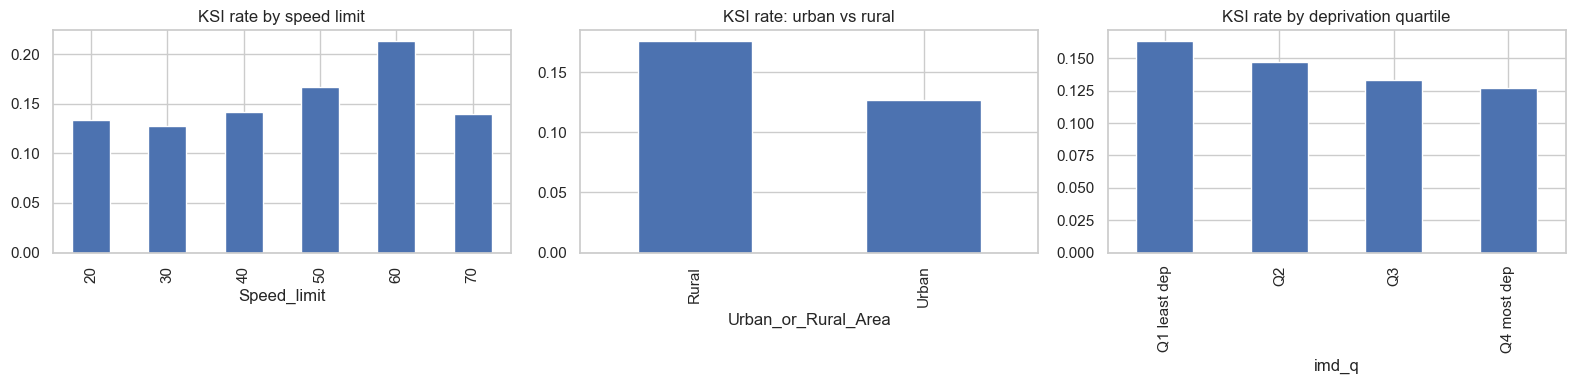

                  n  ksi_rate  rural_share  mean_speed
imd_q                                                 
Q1 least dep  68249     0.163        0.589      44.725
Q2            67122     0.147        0.369      39.222
Q3            68501     0.133        0.236      35.798
Q4 most dep   66849     0.127        0.140      34.019


In [9]:
acc["imd_q"]=pd.qcut(acc[IMD_SCORE],4,labels=["Q1 least dep","Q2","Q3","Q4 most dep"])
fig,ax=plt.subplots(1,3,figsize=(16,4))
acc.groupby("Speed_limit").KSI.mean().plot.bar(ax=ax[0],title="KSI rate by speed limit")
acc.groupby("Urban_or_Rural_Area").KSI.mean().plot.bar(ax=ax[1],title="KSI rate: urban vs rural")
acc.groupby("imd_q",observed=True).KSI.mean().plot.bar(ax=ax[2],title="KSI rate by deprivation quartile")
plt.tight_layout(); plt.savefig(OUTPUT/"eda_ksi_by_context.png",dpi=120,bbox_inches="tight"); plt.show()
print(acc.groupby("imd_q",observed=True).agg(n=("KSI","size"),ksi_rate=("KSI","mean"),
      rural_share=("Urban_or_Rural_Area",lambda s:(s.str.lower()=="rural").mean()),
      mean_speed=("Speed_limit","mean")).round(3).to_string())

📊 **Read‑out / 结果解读 (the surprise):** KSI rate **falls** with deprivation — Q1 least‑deprived **16.3%** → Q4 most‑deprived **12.7%** — the *opposite* of "poor areas suffer more". The mechanism is already visible: rural share **58.9%→14.0%**, mean speed **44.7→34.0 mph**. → real hypothesis to test in §13: **severity tracks the road environment, not deprivation per se**. / KSI 率随贫困**下降**(16.3%→12.7%),与直觉相反;乡村占比/均速同步降→假设:严重度跟道路环境而非贫困(§13 检验)。

## 9. Feature engineering + collinearity (VIF) / 特征工程 + 共线性
**Why / 为什么:** dummy‑encode unordered categories (integer codes would impose a false order); check **VIF** so the interpretable model's coefficients are stable; **IMD is held out of the model** (it is the §‑equity audit variable — using it to predict *and* audit would be circular). / 无序类别哑变量化;VIF 保系数可解释;IMD 不进模型(否则循环)。

In [10]:
work=acc[KEEP_CAT+KEEP_NUM+["KSI","Year","_lad","imd_q",IMD_SCORE]].copy()
work["Hour"]=work["Hour"].fillna(work["Hour"].median())
X=pd.get_dummies(work[KEEP_CAT+KEEP_NUM], columns=KEEP_CAT, drop_first=True, dummy_na=True).astype(float)
X=X.loc[:, ~X.columns.duplicated()]; y=work["KSI"]
Xv=X[KEEP_NUM].assign(const=1.0)
print("VIF (numeric):\n", pd.Series([variance_inflation_factor(Xv.values,i) for i in range(Xv.shape[1])],index=Xv.columns).round(2).to_string())
print("\nFeature matrix:", X.shape, "| positive rate:", round(y.mean(),4))

VIF (numeric):
 Speed_limit     1.00
Hour            1.00
const          16.41

Feature matrix: (270721, 61) | positive rate: 0.1429


📊 **Read‑out / 结果解读:** numeric VIF = **1.00** (no multicollinearity; the high `const` VIF is just the intercept) → the interpretable model's coefficients are stable. Matrix **270,721 × 61**, positive rate 14.3%. / 数值 VIF=1.00(const 高是截距,正常)→ 系数稳定;矩阵 27万×61。

## 10. Models — baseline → stronger benchmark → optional comparisons / 模型分层
**Validation that mirrors use / 贴近用途的验证:** train on **2021**, test **once** on **2022** (out‑of‑time) — the deployment‑realistic estimate. **GroupKFold‑by‑LAD** CV (folds split by district, so the same place can't sit in both train and validation) is used for **model selection / stability**, *not* to replace the out‑of‑time test. / 训 2021/测 2022(时间外推);GroupKFold 按区分组防地点泄漏,仅用于选模型/稳定性,不替代外推测试。

**Model line‑up / 模型分层:**
- **Baseline (interpretable):** Logistic Regression — readable coefficients. / 可解释基线。
- **Stronger benchmark:** XGBoost (+ Random Forest) — captures non‑linear interactions. / 更强基准。
- **Optional comparisons:** Decision Tree, **k‑NN** — breadth only; k‑NN is a weak D3 baseline kept for comparison. / 可选对比(kNN 弱,仅作 D3 对比)。

In [11]:
dev=work.Year==2021; te=work.Year==2022
Xdev,Xte=X[dev.values],X[te.values]; ydev,yte=y[dev.values],y[te.values]
grp=work.loc[dev.values,"_lad"].values
print(f"Develop 2021={len(Xdev):,} (KSI {ydev.mean():.3f}) | Test 2022={len(Xte):,} (KSI {yte.mean():.3f})")
def make():
    return {"LogReg (baseline)":Pipeline([("sc",StandardScaler(with_mean=False)),("clf",LogisticRegression(max_iter=2000,class_weight="balanced",random_state=RANDOM_STATE))]),
            "DecisionTree":DecisionTreeClassifier(max_depth=6,class_weight="balanced",random_state=RANDOM_STATE),
            "kNN":Pipeline([("sc",StandardScaler()),("clf",KNeighborsClassifier(n_neighbors=50,n_jobs=N_JOBS))]),
            "RandomForest":RandomForestClassifier(n_estimators=200,n_jobs=N_JOBS,class_weight="balanced_subsample",random_state=RANDOM_STATE),
            "XGBoost (benchmark)":XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.9,colsample_bytree=0.9,
                                    scale_pos_weight=(ydev==0).sum()/(ydev==1).sum(),eval_metric="aucpr",random_state=RANDOM_STATE,n_jobs=N_JOBS)}
# Split 2021 into fit/validation; select on validation; 2022 stays untouched.
Xtr,Xval,ytr,yval=train_test_split(Xdev,ydev,test_size=0.25,stratify=ydev,random_state=RANDOM_STATE)
gkf=GroupKFold(n_splits=5); rows=[]
for n,m in make().items():
    cv = cross_val_score(m,Xdev,ydev,cv=gkf.split(Xdev,ydev,grp),scoring="roc_auc",n_jobs=N_JOBS).mean() if n!="kNN" else np.nan  # kNN k-fold heavy
    m.fit(Xtr,ytr); va=roc_auc_score(yval,m.predict_proba(Xval)[:,1])
    rows.append([n, round(cv,3) if cv==cv else "—(heavy)", round(va,3), round(average_precision_score(yval,m.predict_proba(Xval)[:,1]),3)])
res=pd.DataFrame(rows,columns=["model","CV ROC-AUC (GroupKFold-LAD)","VAL ROC-AUC","VAL PR-AUC"])
print(res.to_string(index=False))
best="XGBoost (benchmark)"; print("\nDeployment model (best on validation):", best)

Develop 2021=138,011 (KSI 0.146) | Test 2022=132,710 (KSI 0.140)


              model CV ROC-AUC (GroupKFold-LAD)  VAL ROC-AUC  VAL PR-AUC
  LogReg (baseline)                       0.601        0.605       0.209
       DecisionTree                       0.591        0.591       0.193
                kNN                    —(heavy)        0.575       0.187
       RandomForest                       0.538        0.536       0.167
XGBoost (benchmark)                       0.611        0.610       0.211

Deployment model (best on validation): XGBoost (benchmark)


📊 **Read‑out / 结果解读 (a real critical‑evaluation point):** validation ranks **XGBoost 0.610 ≈ LogReg 0.605 > DecisionTree 0.591 > kNN 0.575 ≫ RandomForest 0.537**, and CV ≈ VAL (stable, no over‑fit for the chosen models). The ensemble is **not** automatically better — RandomForest **over‑fits** to 0.54, and regularised XGBoost only just edges a plain logistic. So the signal is **weak and near‑irreducible** from context; XGBoost is the deployment model but the gain over an interpretable baseline is **marginal**. / 验证 XGB0.610≈LogReg0.605>树0.591>kNN0.575≫RF0.537,CV≈VAL(稳、所选模型不过拟合);集成非自动更好(RF 过拟合),XGB 仅微胜逻辑回归→信号弱、近不可约;选 XGBoost 但相对基线提升很小。

## 11. Calibration, cost‑based threshold & honest metrics / 校准 · 成本阈值 · 诚实指标
**Why not accuracy / 为什么不看准确率:** KSI is the minority class (~14.5%), so an all‑"Slight" classifier already scores ~85.5% — useless. We report **ROC‑AUC, PR‑AUC, recall, precision, confusion matrix** and **calibrate** probabilities (reweighting distorts them) before any cost decision. **Why a cost threshold / 为什么按成本选阈值:** a **false negative** = missing a context that produces serious/fatal harm; a **false positive** = attention on a lower‑risk context. KSI harm is costlier, so the threshold should not be the default 0.5 — it is the policy lever. / 不平衡→看 PR‑AUC/召回;先校准;按 FN≫FP 的成本选阈值。

XGBoost (benchmark) (calibrated): VAL ROC-AUC=0.610 | TEST 2022 ROC-AUC=0.607 PR-AUC=0.205

Threshold comparison (2022) — FN costed 5× FP:
 threshold  precision  recall  false_pos  false_neg  expected_cost
      0.10      0.150   0.907      95584       1732         104244
      0.16      0.204   0.399      28959      11168          84799
      0.30      0.345   0.016        571      18295          92046
      0.50      0.000   0.000          0      18596          92980

Cost-optimal threshold (tuned on VAL, 5:1) = 0.160
               precision    recall  f1-score   support

           0      0.884     0.746     0.809    114114
           1      0.204     0.399     0.270     18596

    accuracy                          0.698    132710
   macro avg      0.544     0.573     0.540    132710
weighted avg      0.789     0.698     0.734    132710



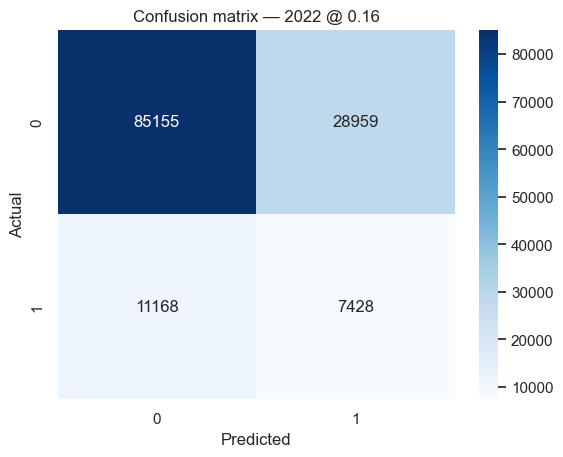

In [12]:
cal=CalibratedClassifierCV(make()[best],method="sigmoid",cv=5).fit(Xtr,ytr)
p_val=cal.predict_proba(Xval)[:,1]; p_te=cal.predict_proba(Xte)[:,1]
print(f"{best} (calibrated): VAL ROC-AUC={roc_auc_score(yval,p_val):.3f} | TEST 2022 ROC-AUC={roc_auc_score(yte,p_te):.3f} PR-AUC={average_precision_score(yte,p_te):.3f}")
# Threshold comparison table the decision-maker can read: precision/recall/FP/FN/expected cost (FN:FP = 5:1)
COST_FN,COST_FP=5.0,1.0; rows=[]
for t in [0.10,0.16,0.30,0.50]:
    pred=(p_te>=t).astype(int); tn,fp,fn,tp=confusion_matrix(yte,pred).ravel()
    rows.append([t,round(precision_score(yte,pred,zero_division=0),3),round(recall_score(yte,pred),3),fp,fn,int(fn*COST_FN+fp*COST_FP)])
print("\nThreshold comparison (2022) — FN costed 5× FP:")
print(pd.DataFrame(rows,columns=["threshold","precision","recall","false_pos","false_neg","expected_cost"]).to_string(index=False))
ths=np.linspace(0.05,0.95,181)
t_star=ths[int(np.argmin([confusion_matrix(yval,(p_val>=t).astype(int)).ravel()@np.array([0,COST_FP,COST_FN,0]) for t in ths]))]
pred=(p_te>=t_star).astype(int)
print(f"\nCost-optimal threshold (tuned on VAL, 5:1) = {t_star:.3f}\n", classification_report(yte,pred,digits=3))
sns.heatmap(confusion_matrix(yte,pred),annot=True,fmt="d",cmap="Blues"); plt.title(f"Confusion matrix — 2022 @ {t_star:.2f}")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.savefig(OUTPUT/"confusion_2022.png",dpi=120,bbox_inches="tight"); plt.show()

📊 **Read‑out / 结果解读:** calibrated XGBoost generalises **stably out‑of‑time** (VAL 0.610 → **2022 0.607**, PR‑AUC 0.205). The threshold table makes the trade‑off explicit: at the cost‑optimal **0.16 (5:1)** recall ≈**0.40** / precision ≈0.20; pushing to 0.10 lifts recall to 0.91 but at ~96k false positives. Accuracy is meaningless here (all‑"Slight" ≈ 85.5%). → the model is a **budget‑sensitive triage / ranking** aid, **not** a precise predictor; the cost ratio is the policy lever. / 校准 XGBoost 时间外推稳(0.610→0.607);阈值表展示权衡:0.16(5:1)召回≈0.40,降到0.10召回0.91但~9.6万误报;准确率无意义→分诊/排序工具,非精准预测,成本比是旋钮。

## 12. What conditions are associated with severity? (SHAP) / 与严重度相关的条件(SHAP)
**Why SHAP / 为什么:** turns the benchmark into readable, policy‑relevant drivers. **SHAP shows *predictive contribution*, not a *causal effect*** — these are associations to prioritise investigation/intervention, not proven causes. / SHAP 是**预测贡献、非因果**。

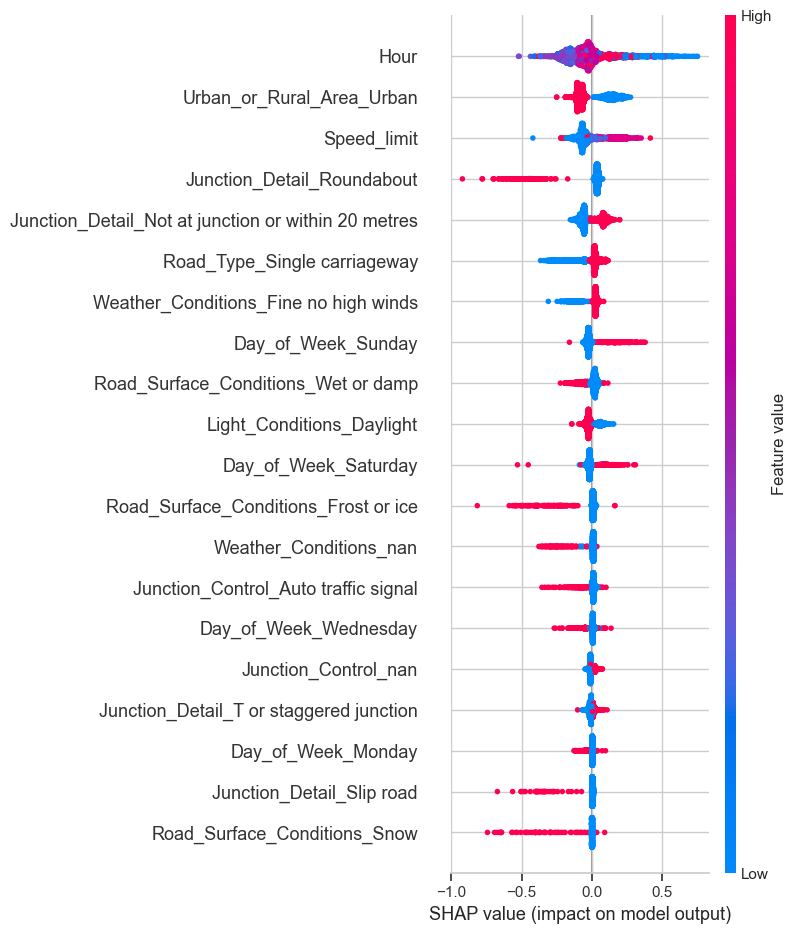

In [13]:
xgb=make()[best].fit(Xtr,ytr)
ex=shap.TreeExplainer(xgb); Xs=Xte.sample(min(3000,len(Xte)),random_state=RANDOM_STATE)
shap.summary_plot(ex.shap_values(Xs),Xs,show=False); plt.savefig(OUTPUT/"shap_summary.png",dpi=120,bbox_inches="tight"); plt.show()

📊 **Read‑out / 结果解读:** SHAP ranks **road‑environment** features at the top — high **speed limit**, **rural** setting, **road type** and poor **light** push toward *severe*; urban/low‑speed pull toward *slight*. **These are predictive associations, NOT causal effects.** Business levers: speed/road‑design/lighting on fast rural roads; corroborates the §8 EDA and §13 equity story. / SHAP 顶部=道路环境(高限速/乡村/路型/差光照);**预测贡献非因果**;杠杆=高速乡村路工程/照明;印证 §8/§13。

## 13. Who bears it? Two‑channel equity analysis / 谁承受?两信道公平分析
**Why two channels / 为什么两条信道:** "who is worse off" has two distinct meanings, and they can point opposite ways. This is an **area‑level** analysis — it must not be read as individual‑level deprivation risk (**ecological fallacy**). / "谁更糟"有两层含义、可相反;这是**地区级**分析,不能推个体(生态学谬误)。
- **Channel 1 — severity *conditional on a recorded collision*** (KSI share by deprivation), with cluster‑robust SE by LAD + a nested control for speed/rurality. / 条件严重度。
- **Channel 2 — *absolute* KSI burden per vehicle‑mile** (joins traffic exposure). / 每车英里绝对负担。

In [14]:
# Channel 1: conditional severity + cluster-robust nested logit
print("Channel 1 — KSI rate (conditional severity) by deprivation quartile:")
print(acc.groupby("imd_q",observed=True).agg(n=("KSI","size"),ksi_rate=("KSI","mean"),
      rural_share=("Urban_or_Rural_Area",lambda s:(s.str.lower()=="rural").mean()),mean_speed=("Speed_limit","mean")).round(3).to_string())
R=acc[["KSI",IMD_SCORE,"Speed_limit","Urban_or_Rural_Area","_lad"]].dropna().copy()
R["imd_z"]=(R[IMD_SCORE]-R[IMD_SCORE].mean())/R[IMD_SCORE].std(); R["rural"]=(R["Urban_or_Rural_Area"].str.lower()=="rural").astype(int)
print("\nCluster-robust SE by LAD — does the deprivation coef attenuate when speed/rural are added?")
for cols,lab in [(["imd_z"],"A: deprivation only"),(["imd_z","Speed_limit","rural"],"B: + speed + rural")]:
    m=sm.Logit(R.KSI, sm.add_constant(R[cols].astype(float))).fit(disp=0,cov_type="cluster",cov_kwds={"groups":R["_lad"]})
    print(f"  {lab:22s} imd_z OR={np.exp(m.params['imd_z']):.3f}  clustered p={m.pvalues['imd_z']:.4f}")

Channel 1 — KSI rate (conditional severity) by deprivation quartile:
                  n  ksi_rate  rural_share  mean_speed
imd_q                                                 
Q1 least dep  68249     0.163        0.589      44.725
Q2            67122     0.147        0.369      39.222
Q3            68501     0.133        0.236      35.798
Q4 most dep   66849     0.127        0.140      34.019

Cluster-robust SE by LAD — does the deprivation coef attenuate when speed/rural are added?


  A: deprivation only    imd_z OR=0.902  clustered p=0.0000


  B: + speed + rural     imd_z OR=0.966  clustered p=0.0329


📊 **Read‑out / 结果解读 (Channel 1):** *conditional* severity is mildly **anti‑regressive** — KSI rate falls 16.3%→12.7% with deprivation. Under cluster‑robust SE by LAD the deprivation odds ratio **attenuates from 0.902 (p<0.001) to 0.966 (p=0.033)** once speed+rural are added → ~⅔ of the apparent effect is the **road environment**, leaving a small fragile residual. This is *given a recorded collision* and is **area‑level (ecological)** — not individual deprivation risk. / 信道1:条件严重度轻微反累退(16.3%→12.7%);聚类稳健下贫困 OR 0.902→0.966(控速度/乡村),约⅔由路况解释、残差小;地区级、非个体。

Exposure-join coverage: 259,874/270,721 rows (96.0%)

Channel 2 — per billion vehicle-miles, by deprivation quartile:
              crash_per_bvm  KSI_per_bvm  KSI_share_pct
dep_q                                                  
Q1 least dep          407.1         59.4           14.6
Q2                    496.4         75.1           15.1
Q3                    704.1         94.4           13.4
Q4 most dep           738.3         91.9           12.5


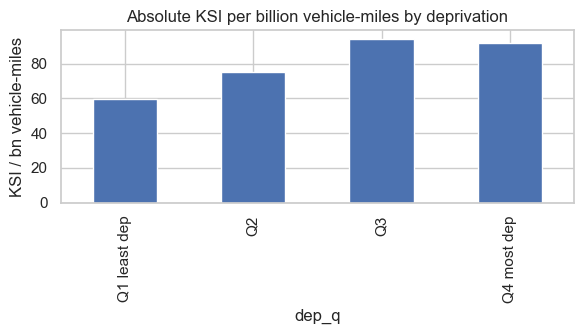

In [15]:
# Channel 2: absolute KSI per billion vehicle-miles (join DfT traffic at the traffic-reporting geography)
lu=pd.read_csv(DATA/F_LAD2CTY); lu["tgt"]=lu.apply(lambda r:r.LTLA17CD if str(r.LTLA17CD)[:3] in("E06","E08","E09","W06") else r.UTLA17CD,axis=1)
acc=acc.merge(lu[["LTLA17NM","tgt"]].assign(_n=lambda d:d.LTLA17NM.map(norm)).drop_duplicates("_n")[["_n","tgt"]],left_on="_lad",right_on="_n",how="left")
tr=pd.read_csv(DATA/F_TRAFFIC); tr=tr[tr.year.isin([2021,2022])].groupby("local_authority_code",as_index=False).all_motor_vehicles.sum()
a=acc.dropna(subset=["tgt"]).groupby("tgt").agg(crashes=("KSI","size"),ksi=("KSI","sum"),imd=(IMD_SCORE,"mean")).reset_index()
a=a.merge(tr,left_on="tgt",right_on="local_authority_code",how="inner").dropna(subset=["imd"])
cov=acc[acc.tgt.isin(a.tgt)].shape[0]; print(f"Exposure-join coverage: {cov:,}/{len(acc):,} rows ({cov/len(acc):.1%})")
a["dep_q"]=pd.qcut(a.imd,4,labels=["Q1 least dep","Q2","Q3","Q4 most dep"])
g=a.groupby("dep_q",observed=True).agg(tk=("ksi","sum"),tc=("crashes","sum"),tv=("all_motor_vehicles","sum"))
g["crash_per_bvm"]=(g.tc/(g.tv/1e9)).round(1); g["KSI_per_bvm"]=(g.tk/(g.tv/1e9)).round(1); g["KSI_share_pct"]=(100*g.tk/g.tc).round(1)
print("\nChannel 2 — per billion vehicle-miles, by deprivation quartile:")
print(g[["crash_per_bvm","KSI_per_bvm","KSI_share_pct"]].to_string())
g[["KSI_per_bvm"]].plot.bar(legend=False,title="Absolute KSI per billion vehicle-miles by deprivation",figsize=(6,3.5))
plt.ylabel("KSI / bn vehicle-miles"); plt.tight_layout(); plt.savefig(OUTPUT/"equity_ksi_per_vehicle_mile.png",dpi=120,bbox_inches="tight"); plt.show()

📊 **Read‑out / 结果解读 (Channel 2 — the reconciliation):** with traffic exposure, crashes per vehicle‑mile **rise monotonically with deprivation (407→738, ~1.8×)** and KSI per vehicle‑mile is **~1.5× higher in the most‑deprived than the least (Q3‑peak 94, Q4 92 vs Q1 59; broadly regressive, peaks at Q3)**, while KSI *share* (severity) stays mildly anti‑regressive (14.6%→12.5%). **Net: the absolute road‑harm burden IS regressive — poorer areas bear ~1.5× the KSI per mile, driven by crash *frequency*** (a descriptive two‑ratio comparison, motor‑vehicle exposure, area‑level). / 信道2:每车英里事故随贫困单调升(407→738,~1.8×)、KSI/英里最贫困区 ~1.5×(Q3峰94/Q4 92 vs Q1 59);严重度占比仍轻微反累退。净:绝对负担累退、由频率驱动(描述性、机动车暴露、地区级)。

## 14. Unsupervised cross‑check — clustering crash contexts / 无监督交叉验证:情境聚类
*A k‑means segmentation (K by elbow/silhouette + a manager funding ~4 playbooks), cross‑checked by an independent hierarchical (Ward) clustering — if both isolate the same group, the segmentation is method‑robust. / k‑means + 层次(Ward)交叉验证。*

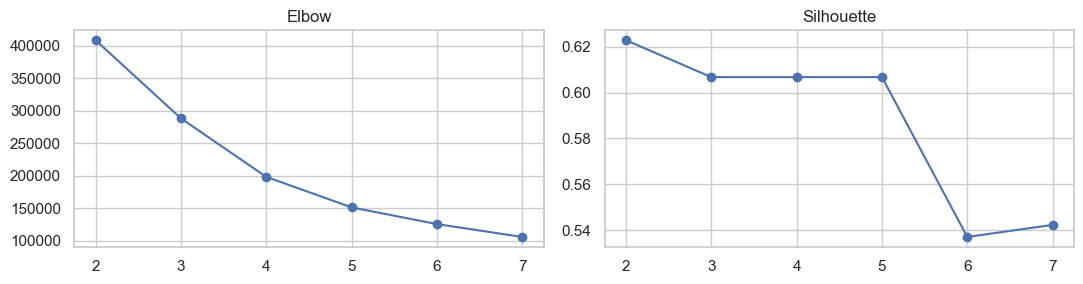

k-means (K=4) profile:
              n  ksi_rate  mean_speed  rural   hour
cluster                                            
0        110414      0.13       31.07   0.00  16.99
1         31428      0.15       33.06   1.00  13.43
2         67109      0.13       31.25   0.00   8.36
3         61770      0.19       62.24   0.96  13.16

Hierarchical (Ward, 5k sample) profile — cross-check:
       n  ksi_rate  mean_speed  rural
hc                                   
0   1086      0.18       62.90   0.91
1   1873      0.14       30.72   0.00
2   1331      0.12       31.06   0.00
3    710      0.16       35.96   1.00


In [16]:
acc["rural_flag"]=(acc["Urban_or_Rural_Area"].str.lower()=="rural").astype(int)
S=acc[["Speed_limit","Hour","rural_flag"]].copy(); S["Hour"]=S["Hour"].fillna(S["Hour"].median())
Z=StandardScaler().fit_transform(S)
inertia,sil=[],[]
for k in range(2,8):
    km=KMeans(k,n_init=10,random_state=RANDOM_STATE).fit(Z); inertia.append(km.inertia_); sil.append(silhouette_score(Z[:5000],km.labels_[:5000]))
fig,ax=plt.subplots(1,2,figsize=(11,3)); ax[0].plot(range(2,8),inertia,"o-"); ax[0].set_title("Elbow"); ax[1].plot(range(2,8),sil,"o-"); ax[1].set_title("Silhouette")
plt.tight_layout(); plt.savefig(OUTPUT/"cluster_k_selection.png",dpi=120,bbox_inches="tight"); plt.show()
acc["cluster"]=KMeans(4,n_init=10,random_state=RANDOM_STATE).fit_predict(Z)
print("k-means (K=4) profile:")
print(acc.groupby("cluster").agg(n=("KSI","size"),ksi_rate=("KSI","mean"),mean_speed=("Speed_limit","mean"),rural=("rural_flag","mean"),hour=("Hour","mean")).round(2).to_string())
samp=acc.sample(5000,random_state=RANDOM_STATE).copy(); Zs=StandardScaler().fit_transform(samp[["Speed_limit","Hour","rural_flag"]].fillna(0))
samp["hc"]=AgglomerativeClustering(n_clusters=4,linkage="ward").fit_predict(Zs)
print("\nHierarchical (Ward, 5k sample) profile — cross-check:")
print(samp.groupby("hc").agg(n=("KSI","size"),ksi_rate=("KSI","mean"),mean_speed=("Speed_limit","mean"),rural=("rural_flag","mean")).round(2).to_string())

📊 **Read‑out / 结果解读:** k‑means (K=4) and hierarchical (Ward) **independently isolate the same hotspot** — a **fast (~62–63 mph) rural** cluster with the highest KSI rate (**0.19 / 0.18**) vs urban low‑speed clusters at ~0.12–0.14. → the fast‑rural high‑severity segment is **method‑robust, not a k‑means artefact**. / k‑means 与层次(Ward)**独立分出同一热点**——高速(~62–63mph)乡村群 KSI 0.19/0.18 最高 vs 城市低速 ~0.12–0.14 → 分群稳健。

## 15. Conclusions & Business Implications / 结论与商业建议
**Answering the three questions / 回答三问:** **Q1 — predictability:** only weak (out‑of‑time ROC‑AUC ≈ **0.61**, stable; ensembles do *not* beat a simple model) → use it to **rank**, not to predict each crash. **Q2 — drivers:** the **road environment** — high speed, rural setting, poor light (SHAP + both clusterings agree). **Q3 — equity (two channels):** *conditional* severity is mildly **anti‑regressive** (fast rural roads sit in less‑deprived areas), but once **exposure** is added the *absolute* KSI burden per vehicle‑mile is **~1.5× higher in the most‑deprived areas** (frequency dominates) → the burden **is** regressive. / Q1 弱可预测(~0.61,集成没赢简单模型)→排序非预测;Q2 道路环境(高速/乡村/差光照);Q3 两信道:条件严重度轻微反累退,但加暴露后每车英里绝对 KSI 负担最贫困区 ~1.5×(频率主导)→负担累退。

**Action‑oriented recommendations (each tied to a finding above) / 行动建议(每条对应上文发现):**
1. **High‑severity rural / high‑speed contexts** (SHAP top drivers + the fast‑rural cluster, §12/§14): speed management, road design, lighting, and emergency‑response coverage — this is where a crash most often turns fatal. / 高速乡村高严重度情境:限速管理、道路设计、照明、应急响应。
2. **Deprived urban / high‑exposure areas** (Channel 2, §13): junction redesign, traffic calming, pedestrian/cyclist protection, crash‑**frequency** reduction — this is where the absolute KSI burden per mile is highest. / 贫困城市/高暴露区:路口改造、交通稳静化、行人骑行保护、降事故频率。
3. **Decision process** (§11): use the model score as a **triage / ranking** input, combined with local engineering judgement — **not** an automatic decision‑maker. / 模型当分诊/排序输入,配本地工程判断,非自动决策。

## 16. Robustness checks / 稳健性检验
*Placed after the main line; each: what was tested · why it matters · whether the conclusion changes. / 每项:测了什么 · 为何重要 · 结论是否变。*

In [17]:
# (a) Sensitivity: does the model lean on Junction_Control (~30% 'unknown')? refit with/without its dummies
jc=[c for c in X.columns if c.startswith("Junction_Control")]
for lab,Xc in [("with Junction_Control",X),("without Junction_Control",X.drop(columns=jc))]:
    mm=make()[best].fit(Xc.loc[Xtr.index],ytr); print(f"  {lab:24s} 2022 ROC-AUC={roc_auc_score(yte,mm.predict_proba(Xc.loc[Xte.index])[:,1]):.3f}")
# (b) Sensitivity: cost ratio -> threshold + 2022 recall
print("\nCost-ratio sensitivity (VAL-tuned threshold, 2022 recall):")
for cfn in [3,5,10,20]:
    tt=ths[int(np.argmin([confusion_matrix(yval,(p_val>=t).astype(int)).ravel()@np.array([0,1,cfn,0]) for t in ths]))]
    print(f"  FN:FP={cfn:2d}:1 -> thr={tt:.3f}, recall={recall_score(yte,(p_te>=tt).astype(int)):.3f}")

  with Junction_Control    2022 ROC-AUC=0.606


  without Junction_Control 2022 ROC-AUC=0.605

Cost-ratio sensitivity (VAL-tuned threshold, 2022 recall):
  FN:FP= 3:1 -> thr=0.265, recall=0.061


  FN:FP= 5:1 -> thr=0.160, recall=0.399
  FN:FP=10:1 -> thr=0.100, recall=0.907
  FN:FP=20:1 -> thr=0.050, recall=0.998


📊 **Read‑out / 结果解读:** **(a)** dropping `Junction_Control` moves 2022 AUC by **0.001 (0.606→0.605)** → the model is *not* leaning on the 30%‑"unknown" artefact (*what:* JC with/without; *why:* a data‑collection artefact could fake signal; *changes conclusion?* no). **(b)** recall swings **6%→40%→91%→100%** as FN:FP goes 3→5→10→20:1 → the cost ratio is genuinely the policy lever (*conclusion unchanged*). / (a)剔 JC 仅动 0.001→不依赖 unknown 伪影;(b)召回随成本比 6%→100%→成本比是旋钮;结论不变。

In [18]:
# (c) Official multi-year STATS19 (2015-2024): is the per-mile regressive burden a COVID artefact? does LSOA-level severity hold?
co=pd.read_csv(DATA/F_STATS19, usecols=["collision_year","collision_severity","local_authority_ons_district","lsoa_of_accident_location"], low_memory=False)
co=co[(co.collision_year>=2015)&(co.collision_year<=2024)].copy(); co["KSI"]=co.collision_severity.isin([1,2]).astype(int)
l2t=dict(zip(lu.LTLA17CD,lu.tgt)); co["tgt"]=co.local_authority_ons_district.map(l2t)
score=dict(zip(imd["Local Authority District code (2019)"] if "Local Authority District code (2019)" in imd else [], []))
f10c=pd.read_excel(DATA/F_IMD_LAD,sheet_name="IMD"); f10c.columns=[x.strip() for x in f10c.columns]
sc=dict(zip(f10c["Local Authority District code (2019)"],f10c["IMD - Average score"]))
d2=pd.DataFrame({"lad":list(l2t)}); d2["tgt"]=d2.lad.map(l2t); d2["imd"]=d2.lad.map(sc); tgt_imd=d2.groupby("tgt").imd.mean()
trf=pd.read_csv(DATA/F_TRAFFIC); trf=trf[(trf.year>=2015)&(trf.year<=2024)].groupby("local_authority_code",as_index=False).all_motor_vehicles.sum()
A=co.dropna(subset=["tgt"]).groupby("tgt").agg(crashes=("KSI","size"),ksi=("KSI","sum")).reset_index(); A["imd"]=A.tgt.map(tgt_imd)
A=A.merge(trf,left_on="tgt",right_on="local_authority_code",how="inner").dropna(subset=["imd"]); A["dep_q"]=pd.qcut(A.imd,4,labels=["Q1","Q2","Q3","Q4"])
G=A.groupby("dep_q",observed=True).agg(tk=("ksi","sum"),tv=("all_motor_vehicles","sum")); G["KSI_per_bvm"]=(G.tk/(G.tv/1e9)).round(1)
print("(c) 2015-2024 KSI per bn vehicle-miles by deprivation:\n", G[["KSI_per_bvm"]].to_string())
f7=pd.read_csv(DATA/F_IMD_LSOA); dcol=[x for x in f7.columns if "Decile" in x and "Multiple" in x][0]; lcol=[x for x in f7.columns if x.startswith("LSOA code")][0]
co["dec"]=co.lsoa_of_accident_location.map(dict(zip(f7[lcol],f7[dcol]))); bb=co.dropna(subset=["dec"])
rho,pv=spearmanr(bb["dec"],bb["KSI"])
print(f"\n(c) LSOA-level severity trend: Spearman rho={rho:.3f}, p={pv:.2g} (negligible tilt; p tiny only due to N={len(bb):,})")

(c) 2015-2024 KSI per bn vehicle-miles by deprivation:
        KSI_per_bvm
dep_q             
Q1            62.0
Q2            75.6
Q3           102.1
Q4            97.5

(c) LSOA-level severity trend: Spearman rho=0.031, p=9.7e-225 (negligible tilt; p tiny only due to N=1,047,806)


📊 **Read‑out / 结果解读:** **(c)** over the full **2015–2024** decade the regressive frequency burden holds — KSI per vehicle‑mile **62→102(Q3)→97.5(Q4), ~1.6×** (*not* a COVID artefact; *conclusion unchanged*). At **LSOA** level the severity tilt is real in direction but **negligible in magnitude** — Spearman ρ=**0.031** (p tiny only because N=1.05M), so the §13 severity channel is small and the ecological‑fallacy worry is not driving it. / (c)2015–24 十年内频率累退依旧(KSI/英里 62→102→97.5,~1.6×,非疫情假象);LSOA 级严重度 ρ=0.031(可忽略,p 小只因 N=105万)→严重度信道很弱、非生态学谬误所致。

## 17. Limitations & future improvements / 局限与未来改进
- **Observational data cannot prove causality** → *future:* a quasi‑experiment (e.g. DID around a new lighting/speed scheme) to test mechanisms. / 观察性非因果 → 准实验。
- **Some fields are only known at/after a collision** (weather, light, surface, vehicle type) → this is risk‑context, not pre‑crash prediction; *future:* pair with road‑asset / speed‑camera / sensor data knowable ex‑ante. / 部分字段事后才知 → 配可事前获取的路产/测速/传感数据。
- **Kaggle extract may differ from official STATS19** (different KSI‑share basis) → *future:* rebuild end‑to‑end on the official open dataset. / Kaggle 与官方口径不同 → 用官方数据重建。
- **Exposure is motor‑vehicle vehicle‑miles only** (no pedestrian/cyclist exposure) → *future:* multi‑modal exposure + AADT by road link. / 暴露仅机动车 → 多模式暴露 + 路段 AADT。
- **Area‑level deprivation risks the ecological fallacy** (not individual risk) → *future:* casualty‑level deprivation / individual covariates where ethically available. / 地区级→生态学谬误 → 个体级协变量。
- **Model performance is moderate (~0.61 AUC)** → suitable for prioritisation, not precise prediction; *future:* richer context (junction geometry, traffic flow, near‑miss data) + spatial models. / 中等性能→宜排序非预测 → 更细情境 + 空间模型。

## 18. Reproducibility checklist / 复现清单
- [x] All paths are **relative** (`./data`, `./outputs`); no machine‑specific absolute paths. / 全相对路径。
- [x] All required data files are listed (the *Paths & files* cell) with sources (§3). / 数据文件+来源已列。
- [x] **Random seeds fixed** (`RANDOM_STATE=42`, `np.random.seed`). / 种子固定。
- [x] **Train/test logic documented**: train 2021 / select on a 2021 validation slice / test once on 2022. / 划分逻辑已记录。
- [x] **Leakage variables excluded** with a logged reason table (§5). / 泄漏变量带理由剔除。
- [x] **Outputs regenerable** → figures written to `./outputs/`. / 输出可重生成。
- [x] **No parallel/multiprocessing noise** (`N_JOBS=1`); only benign library warnings suppressed. / 无并行噪音。
- [x] **Runs top‑to‑bottom** (`Run All`) with no red traceback. / 一键从头跑通。

## 19. AI usage disclosure & References / AI 使用声明与参考文献 (not in word count / 不计入字数)
**AI disclosure:** WHY — accelerate scaffolding/structure + a simulated peer‑review that hardened the design; WHAT — notebook skeleton, join logic, evaluation/robustness pipelines + debugging; WHICH — Claude (Anthropic); WHERE — code structure/comments; **all statistical choices, claim wording and conclusions reviewed & written by me.**

**References (WBS Harvard) — ⚠️ verify before submission / 提交前核对(勿伪造):**
- xavierberge (n.d.) *Road Accident Dataset* [dataset]. Kaggle. (verify access date)
- Ministry of Housing, Communities & Local Government (2019) *English Indices of Deprivation 2019* [dataset]. gov.uk.
- Department for Transport — *Road safety data (STATS19)* + *Road traffic statistics* [datasets]. gov.uk.
- **[VERIFY — DfT *Reported road casualties Great Britain* for the KSI convention + a motivating statistic.]**
- **[VERIFY — one peer‑reviewed source on the UK urban/rural casualty‑severity gradient.]**